In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp /content/drive/MyDrive/CCD_CLIPS_Par.zip /content/

In [3]:
!unzip -q /content/CCD_CLIPS_Par.zip -d /content/

In [4]:
!mv /content/content/drive/MyDrive/CCD_CLIPS_Par /content/

In [5]:
CLIP_DIR = "/content/CCD_CLIPS_Par"

In [6]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import (
    Dense, Dropout, LSTM,
    TimeDistributed, GlobalAveragePooling2D
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.applications import MobileNetV2
from sklearn.utils.class_weight import compute_class_weight

In [7]:
SEQ_LEN = 16
IMG_SIZE = 112
BATCH_SIZE = 4
EPOCHS = 15   # fine-tuning needs fewer epochs
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

CLIP_DIR = "/content/CCD_CLIPS_Par"

In [8]:
train_files = np.array(tf.io.gfile.glob(CLIP_DIR + "/train/*.npz"))
val_files   = np.array(tf.io.gfile.glob(CLIP_DIR + "/val/*.npz"))
test_files  = np.array(tf.io.gfile.glob(CLIP_DIR + "/test/*.npz"))

print("Train clips:", len(train_files))
print("Val clips:", len(val_files))
print("Test clips:", len(test_files))

Train clips: 9753
Val clips: 1722
Test clips: 2025


In [9]:
def clip_file_generator(file_paths):

    for path in file_paths:
        data = np.load(path)
        yield data["clip"].astype(np.float32), int(data["label"])

In [10]:
output_signature = (
    tf.TensorSpec((SEQ_LEN, IMG_SIZE, IMG_SIZE, 3), tf.float32),
    tf.TensorSpec((), tf.int32)
)

train_ds = tf.data.Dataset.from_generator(
    lambda: clip_file_generator(train_files),
    output_signature=output_signature
).shuffle(2000).repeat().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    lambda: clip_file_generator(val_files),
    output_signature=output_signature
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    lambda: clip_file_generator(test_files),
    output_signature=output_signature
).batch(BATCH_SIZE)

In [11]:
def load_labels(file_list):
    return np.array([int(np.load(f)["label"]) for f in file_list])

y_train = load_labels(train_files)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight = dict(enumerate(class_weights))

In [12]:
def build_finetune_model():

    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # 🔥 UNFREEZE PART OF MODEL
    base_model.trainable = True

    for layer in base_model.layers[:-20]:
        layer.trainable = False

    inputs = tf.keras.Input(
        shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE, 3)
    )

    x = TimeDistributed(base_model)(inputs)

    x = TimeDistributed(GlobalAveragePooling2D())(x)

    x = LSTM(64)(x)

    x = Dropout(0.5)(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    # 🔥 LOWER LR for fine-tuning
    model.compile(
        optimizer=Adam(1e-5),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


model = build_finetune_model()
model.summary()

/tmp/ipykernel_12143/2416729766.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 112, 112,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 16, 4, 4, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,602,369 (9.93 MB)

 Trainable params: 1,550,465 (5.91 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [13]:
steps_per_epoch = len(train_files) // BATCH_SIZE
validation_steps = len(val_files) // BATCH_SIZE

In [14]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/mobilenet_finetuned.keras",
    monitor="val_loss",
    save_best_only=True
)

In [15]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,

    class_weight=class_weight,

    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True),
        checkpoint
    ]
)

Epoch 1/15
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 606s 202ms/step - accuracy: 0.8200 - loss: 0.3933 - val_accuracy: 0.9733 - val_loss: 0.1384
Epoch 2/15
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 471s 193ms/step - accuracy: 0.9110 - loss: 0.2378 - val_accuracy: 0.9802 - val_loss: 0.1051
Epoch 3/15
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 476s 195ms/step - accuracy: 0.9321 - loss: 0.1932 - val_accuracy: 0.9831 - val_loss: 0.0785
Epoch 4/15
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 477s 196ms/step - accuracy: 0.9468 - loss: 0.1603 - val_accuracy: 0.9849 - val_loss: 0.0682
Epoch 5/15
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 477s 195ms/step - accuracy: 0.9579 - loss: 0.1366 - val_accuracy: 0.9826 - val_loss: 0.0627
Epoch 6/15
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 480s 197ms/step - accuracy: 0.9605 - loss: 0.1188 - val_accuracy: 0.9843 - val_loss: 0.0640
Epoch 7/15
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 476s 195ms/step - accuracy: 0.9688 - loss: 0.1066 - val_accuracy: 0.9826 - val_loss: 0.0650
Epoch 8/15
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 477s 196ms/step - ac

In [16]:
model.evaluate(test_ds)

507/507 ━━━━━━━━━━━━━━━━━━━━ 58s 114ms/step - accuracy: 0.9802 - loss: 0.0555


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[0.055459730327129364, 0.980246901512146]

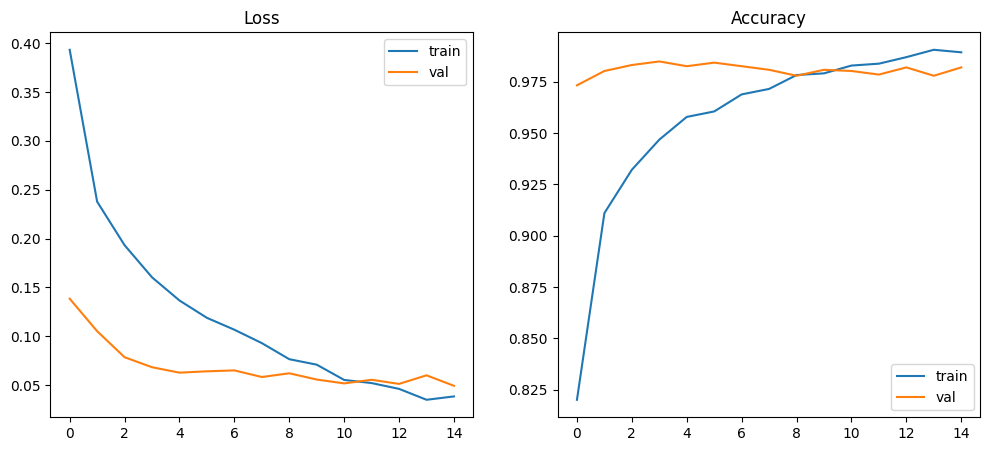

In [17]:
def plot_training(history):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title("Accuracy")
    plt.legend()

    plt.savefig(
        "/content/drive/MyDrive/mobilenet_finetune_curves.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

plot_training(history)

In [18]:
from collections import defaultdict
import os
import numpy as np

def video_level_evaluation(model, test_files):

    video_preds = defaultdict(list)
    video_labels = {}

    for file in test_files:

        data = np.load(file)

        clip = data["clip"]
        label = int(data["label"])

        pred = model.predict(clip[np.newaxis], verbose=0)[0][0]

        # extract video id
        vid_id = os.path.basename(file).split("_")[1]

        video_preds[vid_id].append(pred)
        video_labels[vid_id] = label

    correct = 0

    for vid in video_preds:

        avg_pred = np.mean(video_preds[vid])
        final_pred = int(avg_pred > 0.5)

        if final_pred == video_labels[vid]:
            correct += 1

    acc = correct / len(video_preds)

    print("Video-level accuracy:", acc)

    return acc

In [19]:
video_acc = video_level_evaluation(model, test_files)

Video-level accuracy: 0.9881481481481481


In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def video_confusion_matrix(model, test_files):

    video_preds = defaultdict(list)
    video_labels = {}

    for file in test_files:

        data = np.load(file)

        clip = data["clip"]
        label = int(data["label"])

        pred = model.predict(clip[np.newaxis], verbose=0)[0][0]

        vid_id = os.path.basename(file).split("_")[1]

        video_preds[vid_id].append(pred)
        video_labels[vid_id] = label

    y_true = []
    y_pred = []

    for vid in video_preds:

        final_pred = int(np.mean(video_preds[vid]) > 0.5)

        y_true.append(video_labels[vid])
        y_pred.append(final_pred)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Video-Level Confusion Matrix")

    plt.show()

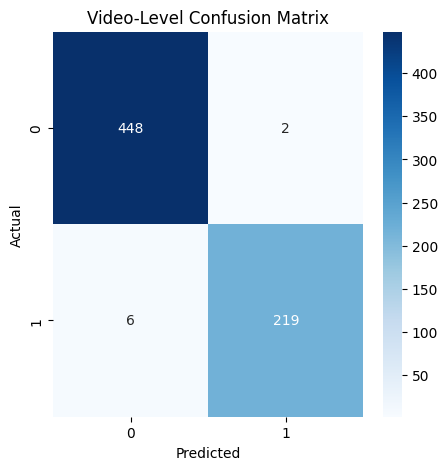

In [22]:
video_confusion_matrix(model, test_files)

In [23]:
from sklearn.metrics import classification_report

def video_classification_report(model, test_files):

    video_preds = defaultdict(list)
    video_labels = {}

    for file in test_files:

        data = np.load(file)

        clip = data["clip"]
        label = int(data["label"])

        pred = model.predict(clip[np.newaxis], verbose=0)[0][0]

        vid_id = os.path.basename(file).split("_")[1]

        video_preds[vid_id].append(pred)
        video_labels[vid_id] = label

    y_true = []
    y_pred = []

    for vid in video_preds:

        final_pred = int(np.mean(video_preds[vid]) > 0.5)

        y_true.append(video_labels[vid])
        y_pred.append(final_pred)

    print(classification_report(y_true, y_pred))

In [24]:
video_classification_report(model, test_files)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       450
           1       0.99      0.97      0.98       225

    accuracy                           0.99       675
   macro avg       0.99      0.98      0.99       675
weighted avg       0.99      0.99      0.99       675

